In [146]:
import os
import sys
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.collections import LineCollection
from scipy.ndimage import gaussian_filter1d
from matplotlib import gridspec
import torch 
# Add parent directory to sys.path
parent_dir = os.path.abspath(os.path.join(os.getcwd(), '..'))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

work_path = "M:/1confiProj/"
os.chdir(work_path)
from scripts.experiments import ModelEvaluator
from utils.plot_function import *

In [147]:
ev=ModelEvaluator('base_clamp')
m_lst= [1]

## first investigate for the congruent cases, why the high reliability will have the bigger interval

In [148]:
df_sim, sim_post, sim_post_conf, xA, xV, post_cdf, post_pdf, bin_est, trial_indices, binSize, nbin,ntrial = ev.get_model_prediction(1, 2, nsim=1000, interimOutput=True, print_param=True)


Params for estimation are
sig_Vrh: 1.5558133421823008
sig_Vrl: 6.266840040683746
sig_A: 6.370790576562285
kC1: 3.830966478831388
mC1: 2.035304978489876
sig_P: 8.491161251440644
p_com: 0.46353488489985467
rng: 0.4821576453745365
sig_rs: 0.00018135197971647478
sig_rconf: 1.9667664592879044
sig_rc: 0.24349723106555346


In [149]:
df_sim

,AudLoc,VisLoc,VisRel,blockType,RespLoc,CISize,Sources,ConfLevel,sub_id,delta_VA,VisRelLabel,bias,flipBias,abs_delta_VA
0,-10.0,-10.0,1.0,1.0,-8.942588,2.080604,1.0,83.0,2,0.0,High,1.057412,1.057412,0.0
1,-10.0,-10.0,1.0,1.0,-10.196853,2.762402,1.0,24.0,2,0.0,High,-0.196853,-0.196853,0.0
2,-10.0,-10.0,1.0,1.0,-9.816277,4.948888,1.0,42.0,2,0.0,High,0.183723,0.183723,0.0
3,-10.0,-10.0,1.0,1.0,-10.118845,4.570308,1.0,100.0,2,0.0,High,-0.118845,-0.118845,0.0
4,-10.0,-10.0,1.0,1.0,-7.932203,5.852503,1.0,74.0,2,0.0,High,2.067797,2.067797,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,10.0,10.0,2.0,0.0,0.747761,4.755631,2.0,44.0,2,0.0,Low,-9.252239,-9.252239,0.0
99996,10.0,10.0,2.0,0.0,11.360842,6.987103,1.0,41.0,2,0.0,Low,1.360842,1.360842,0.0
99997,10.0,10.0,2.0,0.0,3.992975,4.191218,1.0,35.0,2,0.0,Low,-6.007026,-6.007026,0.0
99998,10.0,10.0,2.0,0.0,13.967129,8.392758,1.0,66.0,2,0.0,Low,3.967129,3.967129,0.0


In [150]:
audloc = 10
cj = 2
cong_mask = (df_sim.blockType==1) & (df_sim.VisLoc==0.0)& (df_sim.AudLoc==audloc) & (df_sim.Sources==cj)
df_sim = df_sim[cong_mask].reset_index(drop=True).copy()
sim_post = sim_post[cong_mask,:]
sim_post_conf = sim_post_conf[cong_mask,:]
xA = xA[cong_mask]
xV = xV[cong_mask]
post_cdf = post_cdf[:, cong_mask]
post_pdf = post_pdf[:, cong_mask]
bin_est = bin_est[cong_mask]
high_rel_mask = df_sim.VisRel==1
low_rel_mask = df_sim.VisRel==2

In [151]:
high_rel_mask.sum()

np.int64(666)

In [152]:
post_cdf.size()

torch.Size([200, 1297])

In [153]:
df_sim.loc[df_sim.VisRel==2]

,AudLoc,VisLoc,VisRel,blockType,RespLoc,CISize,Sources,ConfLevel,sub_id,delta_VA,VisRelLabel,bias,flipBias,abs_delta_VA
666,10.0,0.0,2.0,1.0,1.937794,7.233402,2.0,80.0,2,-10.0,Low,-8.062206,8.062206,10.0
667,10.0,0.0,2.0,1.0,5.130948,10.185481,2.0,44.0,2,-10.0,Low,-4.869052,4.869052,10.0
668,10.0,0.0,2.0,1.0,5.332965,6.997928,2.0,74.0,2,-10.0,Low,-4.667035,4.667035,10.0
669,10.0,0.0,2.0,1.0,4.699497,6.325022,2.0,65.0,2,-10.0,Low,-5.300503,5.300503,10.0
670,10.0,0.0,2.0,1.0,2.686920,8.804027,2.0,28.0,2,-10.0,Low,-7.313080,7.313080,10.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1292,10.0,0.0,2.0,1.0,3.042523,6.061769,2.0,56.0,2,-10.0,Low,-6.957478,6.957478,10.0
1293,10.0,0.0,2.0,1.0,12.740093,10.518875,2.0,36.0,2,-10.0,Low,2.740093,-2.740093,10.0
1294,10.0,0.0,2.0,1.0,16.502768,8.321219,2.0,100.0,2,-10.0,Low,6.502768,-6.502768,10.0
1295,10.0,0.0,2.0,1.0,3.813948,6.946760,2.0,29.0,2,-10.0,Low,-6.186051,6.186051,10.0


<Axes: xlabel='RespLoc', ylabel='Count'>

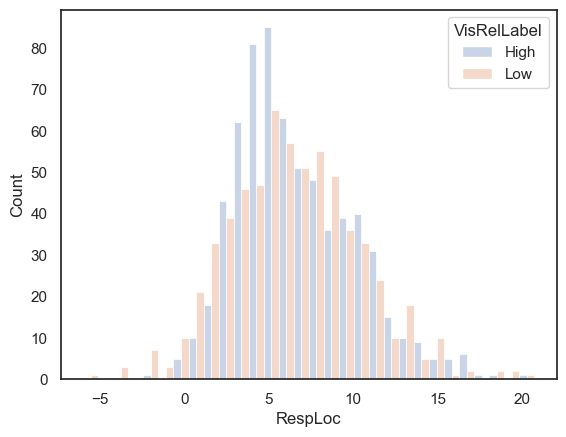

In [154]:
sns.histplot(data=df_sim, x='RespLoc', hue='VisRelLabel', alpha=0.3,multiple='dodge')

<Axes: xlabel='CISize', ylabel='Count'>

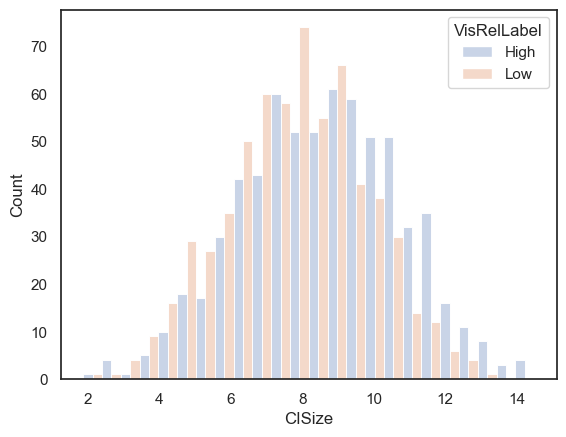

In [155]:
sns.histplot(data=df_sim, x='CISize', hue='VisRelLabel', alpha=0.3,multiple='dodge')

<Axes: xlabel='CIBin', ylabel='percept_bias'>

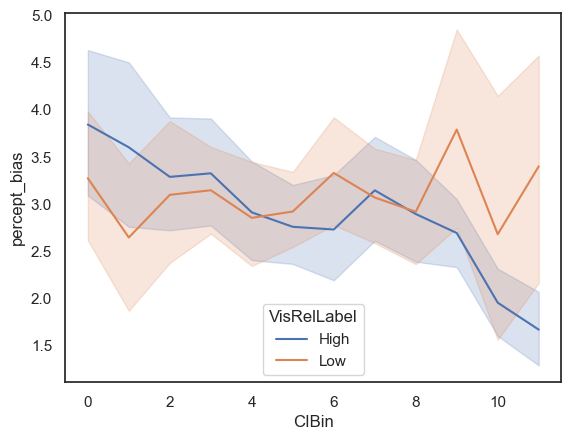

In [156]:
# first bin the CI size
# ci range
ci_bins = np.append(0, np.linspace(df_sim['CISize'].quantile(0.05), df_sim['CISize'].quantile(0.95), 11))  # 10 bins
ci_bins = np.append(ci_bins, df_sim['CISize'].max()+0.1)  # ensure the max value is included
df_sim['CIBin'] = pd.cut(df_sim['CISize'], bins=ci_bins, labels=False)
ci_labels = [(ci_bins[i] + ci_bins[i+1]) / 2 for i in range(len(ci_bins)-1)]
df_summary = df_sim.groupby('VisRelLabel')['RespLoc'].mean().reset_index()
df_sim = pd.merge(df_sim, df_summary, on='VisRelLabel', suffixes=('', '_mean')).reset_index(drop=True)
df_sim['percept_bias'] = (df_sim['RespLoc'] - df_sim['RespLoc_mean']).abs()
sns.lineplot(data=df_sim, x='CIBin', y='percept_bias', hue='VisRelLabel')

In [157]:
post_pdf_h = post_pdf[:, high_rel_mask]
post_pdf_l = post_pdf[:, low_rel_mask]


In [158]:
Range=100
half_range = Range / 2 + binSize / 2
        
# Create bin boundaries on GPU
responseLoc_boundaries = torch.linspace(-half_range, half_range, steps=nbin - 1)
responseLoc_boundaries_labels = [(responseLoc_boundaries[i] + responseLoc_boundaries[i+1]) / 2 for i in range(len(responseLoc_boundaries)-1)]
responseLoc_boundaries_labels = torch.cat((torch.tensor([-half_range]), torch.tensor(responseLoc_boundaries_labels), torch.tensor([half_range])))

In [159]:
len(responseLoc_boundaries_labels)

200

In [160]:
len(torch.mean(post_pdf_h, axis=1))

200

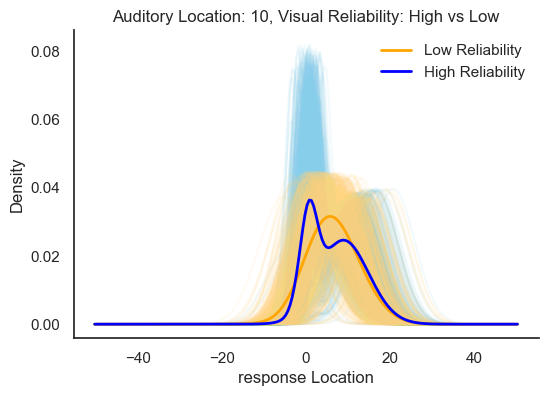

In [161]:
fig, axs = plt.subplots(1, 1, figsize=(6, 4))
for i in range(post_pdf_h.shape[1]):
    sns.lineplot(x=responseLoc_boundaries_labels, y=post_pdf_h[:,i], color='skyblue', alpha = 0.1)
for i in range(post_pdf_l.shape[1]):
    sns.lineplot(x=responseLoc_boundaries_labels, y=post_pdf_l[:,i], color='#FFD580', alpha = 0.1)
sns.lineplot(x=responseLoc_boundaries_labels, y=torch.mean(post_pdf_l, axis=1), color='orange', linewidth=2, label='Low Reliability')
sns.lineplot(x=responseLoc_boundaries_labels, y=torch.mean(post_pdf_h, axis=1), color='blue', linewidth=2, label='High Reliability')
axs.legend(frameon=False)
axs.set_xlabel('response Location')
axs.set_ylabel('Density')
axs.spines[['top', 'right']].set_visible(False)
axs.set_title(f'Auditory Location: {audloc}, Visual Reliability: High vs Low')

#axs.set_spine(left=True, bottom=True)
plt.show()

In [164]:
df_sim['percept_bias'].median()

np.float32(2.5319872)

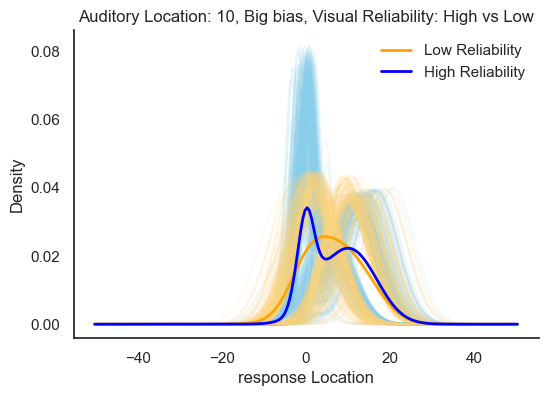

In [165]:
# make it bigger response bias and smaller responser bias
big_bias_mask = df_sim['percept_bias'] >= df_sim['percept_bias'].median()
small_bias_mask = df_sim['percept_bias'] < df_sim['percept_bias'].median()

post_pdf_h = post_pdf[:, high_rel_mask & big_bias_mask]
post_pdf_l = post_pdf[:, low_rel_mask& big_bias_mask]

fig, axs = plt.subplots(1, 1, figsize=(6, 4))
for i in range(post_pdf_h.shape[1]):
    sns.lineplot(x=responseLoc_boundaries_labels, y=post_pdf_h[:,i], color='skyblue', alpha = 0.1)
for i in range(post_pdf_l.shape[1]):
    sns.lineplot(x=responseLoc_boundaries_labels, y=post_pdf_l[:,i], color='#FFD580', alpha = 0.1)
sns.lineplot(x=responseLoc_boundaries_labels, y=torch.mean(post_pdf_l, axis=1), color='orange', linewidth=2, label='Low Reliability')
sns.lineplot(x=responseLoc_boundaries_labels, y=torch.mean(post_pdf_h, axis=1), color='blue', linewidth=2, label='High Reliability')
axs.legend(frameon=False)
axs.set_xlabel('response Location')
axs.set_ylabel('Density')
axs.spines[['top', 'right']].set_visible(False)
axs.set_title(f'Auditory Location: {audloc}, Big bias, Visual Reliability: High vs Low')

#axs.set_spine(left=True, bottom=True)
plt.show()


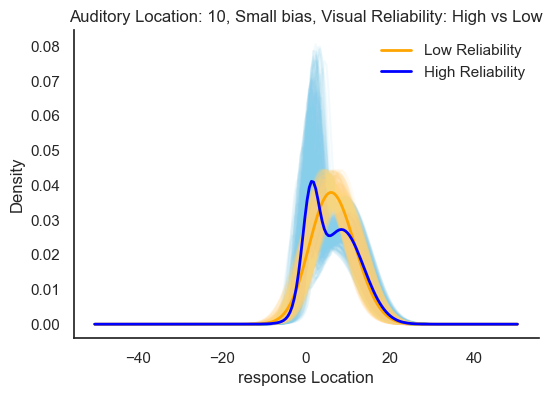

In [166]:
# make it bigger response bias and smaller responser bias
big_bias_mask = df_sim['percept_bias'] >= df_sim['percept_bias'].median()
small_bias_mask = df_sim['percept_bias'] < df_sim['percept_bias'].median()

post_pdf_h = post_pdf[:, high_rel_mask & small_bias_mask]
post_pdf_l = post_pdf[:, low_rel_mask& small_bias_mask]

fig, axs = plt.subplots(1, 1, figsize=(6, 4))
for i in range(post_pdf_h.shape[1]):
    sns.lineplot(x=responseLoc_boundaries_labels, y=post_pdf_h[:,i], color='skyblue', alpha = 0.1)
for i in range(post_pdf_l.shape[1]):
    sns.lineplot(x=responseLoc_boundaries_labels, y=post_pdf_l[:,i], color='#FFD580', alpha = 0.1)
sns.lineplot(x=responseLoc_boundaries_labels, y=torch.mean(post_pdf_l, axis=1), color='orange', linewidth=2, label='Low Reliability')
sns.lineplot(x=responseLoc_boundaries_labels, y=torch.mean(post_pdf_h, axis=1), color='blue', linewidth=2, label='High Reliability')
axs.legend(frameon=False)
axs.set_xlabel('response Location')
axs.set_ylabel('Density')
axs.spines[['top', 'right']].set_visible(False)
axs.set_title(f'Auditory Location: {audloc}, Small bias, Visual Reliability: High vs Low')

#axs.set_spine(left=True, bottom=True)
plt.show()


C:\Users\wenlou\AppData\Local\Temp\ipykernel_24016\807963439.py:13: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axs.legend(frameon=False)


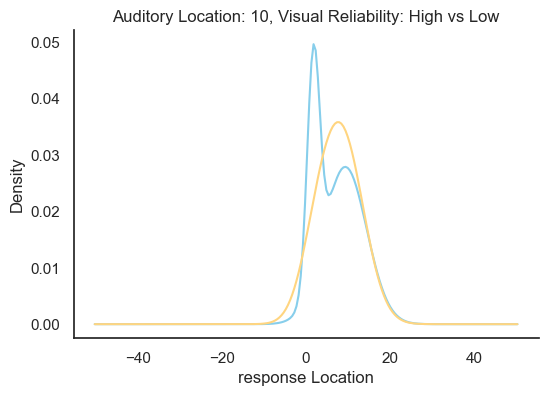

In [172]:
# make it bigger response bias and smaller responser bias
big_bias_mask = df_sim['percept_bias'] >= df_sim['percept_bias'].median()
small_bias_mask = df_sim['percept_bias'] < df_sim['percept_bias'].median()
i=4
post_pdf_h = post_pdf[:, high_rel_mask & small_bias_mask]
post_pdf_l = post_pdf[:, low_rel_mask& small_bias_mask]

fig, axs = plt.subplots(1, 1, figsize=(6, 4))
sns.lineplot(x=responseLoc_boundaries_labels, y=post_pdf_h[:,i], color='skyblue')
sns.lineplot(x=responseLoc_boundaries_labels, y=post_pdf_l[:,i], color='#FFD580')
#sns.lineplot(x=responseLoc_boundaries_labels, y=torch.mean(post_pdf_l, axis=1), color='orange', linewidth=2, label='Low Reliability')
#sns.lineplot(x=responseLoc_boundaries_labels, y=torch.mean(post_pdf_h, axis=1), color='blue', linewidth=2, label='High Reliability')
axs.legend(frameon=False)
axs.set_xlabel('response Location')
axs.set_ylabel('Density')
axs.spines[['top', 'right']].set_visible(False)
axs.set_title(f'Auditory Location: {audloc}, Visual Reliability: High vs Low')

#axs.set_spine(left=True, bottom=True)
plt.show()
